In [1]:
import pandas as pd
import numpy as np
import string
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer

from scipy.sparse import hstack

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

import pickle


In [2]:
df = pd.read_csv("Data/FakeNewsNet.csv")
df_copy = df.copy()
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/FakeNewsNet.csv'

In [ ]:
df.shape

(23196, 5)

In [ ]:
df.columns

Index(['title', 'news_url', 'source_domain', 'tweet_num', 'real'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 906.2+ KB


In [ ]:
df.describe(include='all')

,title,news_url,source_domain,tweet_num,real
count,23196,22866,22866,23196.000000,23196.000000
unique,21724,21658,2441,NaN,NaN
top,Connecting People Through News,https://www.thewrap.com/this-is-us-everything-...,people.com,NaN,NaN
freq,20,11,1786,NaN,NaN
mean,NaN,NaN,NaN,88.956803,0.751897
std,NaN,NaN,NaN,488.694592,0.431921
min,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,11.000000,1.000000
50%,NaN,NaN,NaN,37.000000,1.000000
75%,NaN,NaN,NaN,65.000000,1.000000


In [ ]:
df.isnull().sum()

,0
title,0
news_url,330
source_domain,330
tweet_num,0
real,0


In [ ]:
df['real'].value_counts()

,count
real,
1,17441
0,5755


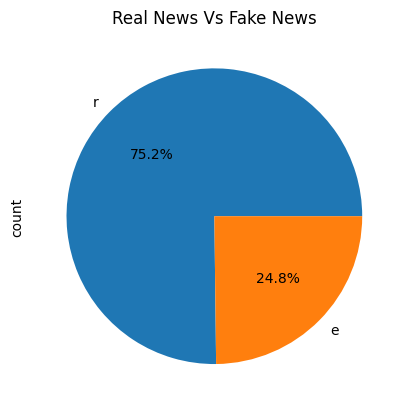

In [ ]:
df['real'].value_counts().plot(kind='pie',labels='real', autopct='%1.1f%%')
plt.title("Real News Vs Fake News")
plt.show()

In [ ]:
df['news_length'] = df['title'].apply(len)
df['news_length'].describe()

,news_length
count,23196.000000
mean,68.303328
std,23.287987
min,10.000000
25%,55.000000
50%,68.000000
75%,84.000000
max,340.000000


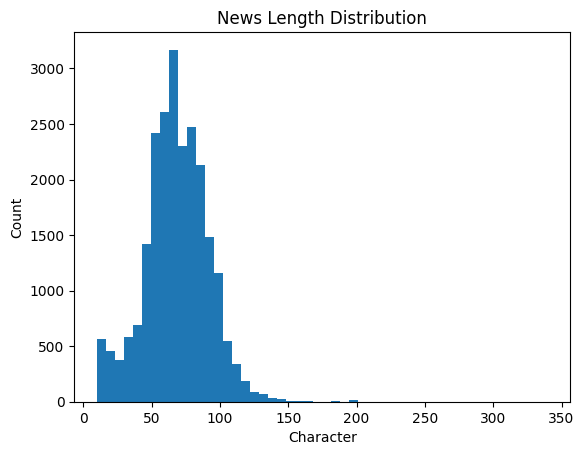

In [ ]:
plt.hist(df['news_length'], bins=50)
plt.title("News Length Distribution")
plt.xlabel("Character")
plt.ylabel("Count")
plt.show()

In [ ]:
df['word_count'] = df['title'].apply(
    lambda x: len(str(x).split())
)
df['word_count'].describe()

,word_count
count,23196.000000
mean,11.161192
std,3.977693
min,1.000000
25%,9.000000
50%,11.000000
75%,14.000000
max,53.000000


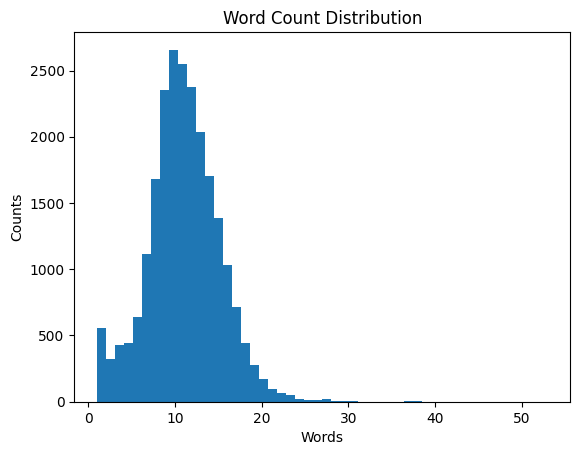

In [ ]:
plt.hist(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65281 (\N{FULLWIDTH EXCLAMATION MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


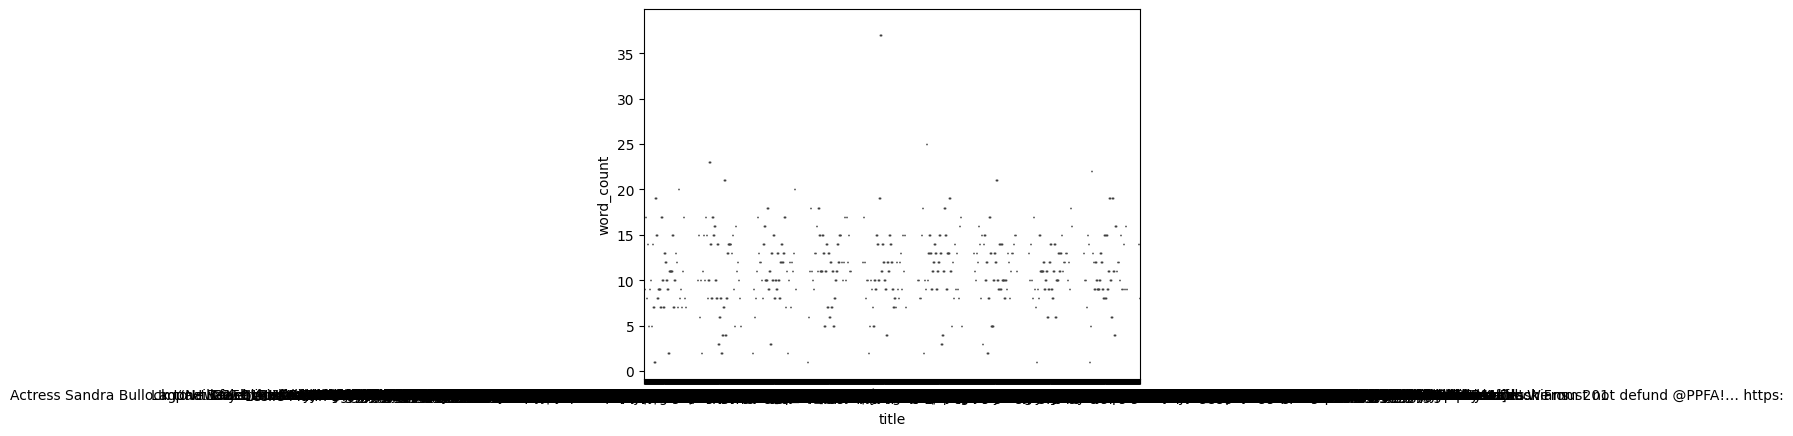

In [ ]:
Df_samples = df.sample(n=2000, random_state=42)
sns.boxplot(
    x="title",
    y="word_count",
    data=Df_samples,
    showfliers=False
)
plt.show()


In [ ]:
all_words = " ".join(df['title'].astype(str))

words = all_words.split()

common_words = Counter(words).most_common(20)

common_words

[('and', 4450),
 ('to', 3765),
 ('the', 3712),
 ('of', 2783),
 ('in', 2439),
 ('a', 2163),
 ('on', 2156),
 ('The', 2101),
 ('for', 1761),
 ('Is', 1729),
 ('Her', 1651),
 ('With', 1388),
 ('at', 1322),
 ('&', 1237),
 ('with', 1174),
 ('After', 950),
 ('To', 949),
 ('Kardashian', 946),
 ('New', 815),
 ('Jennifer', 793)]

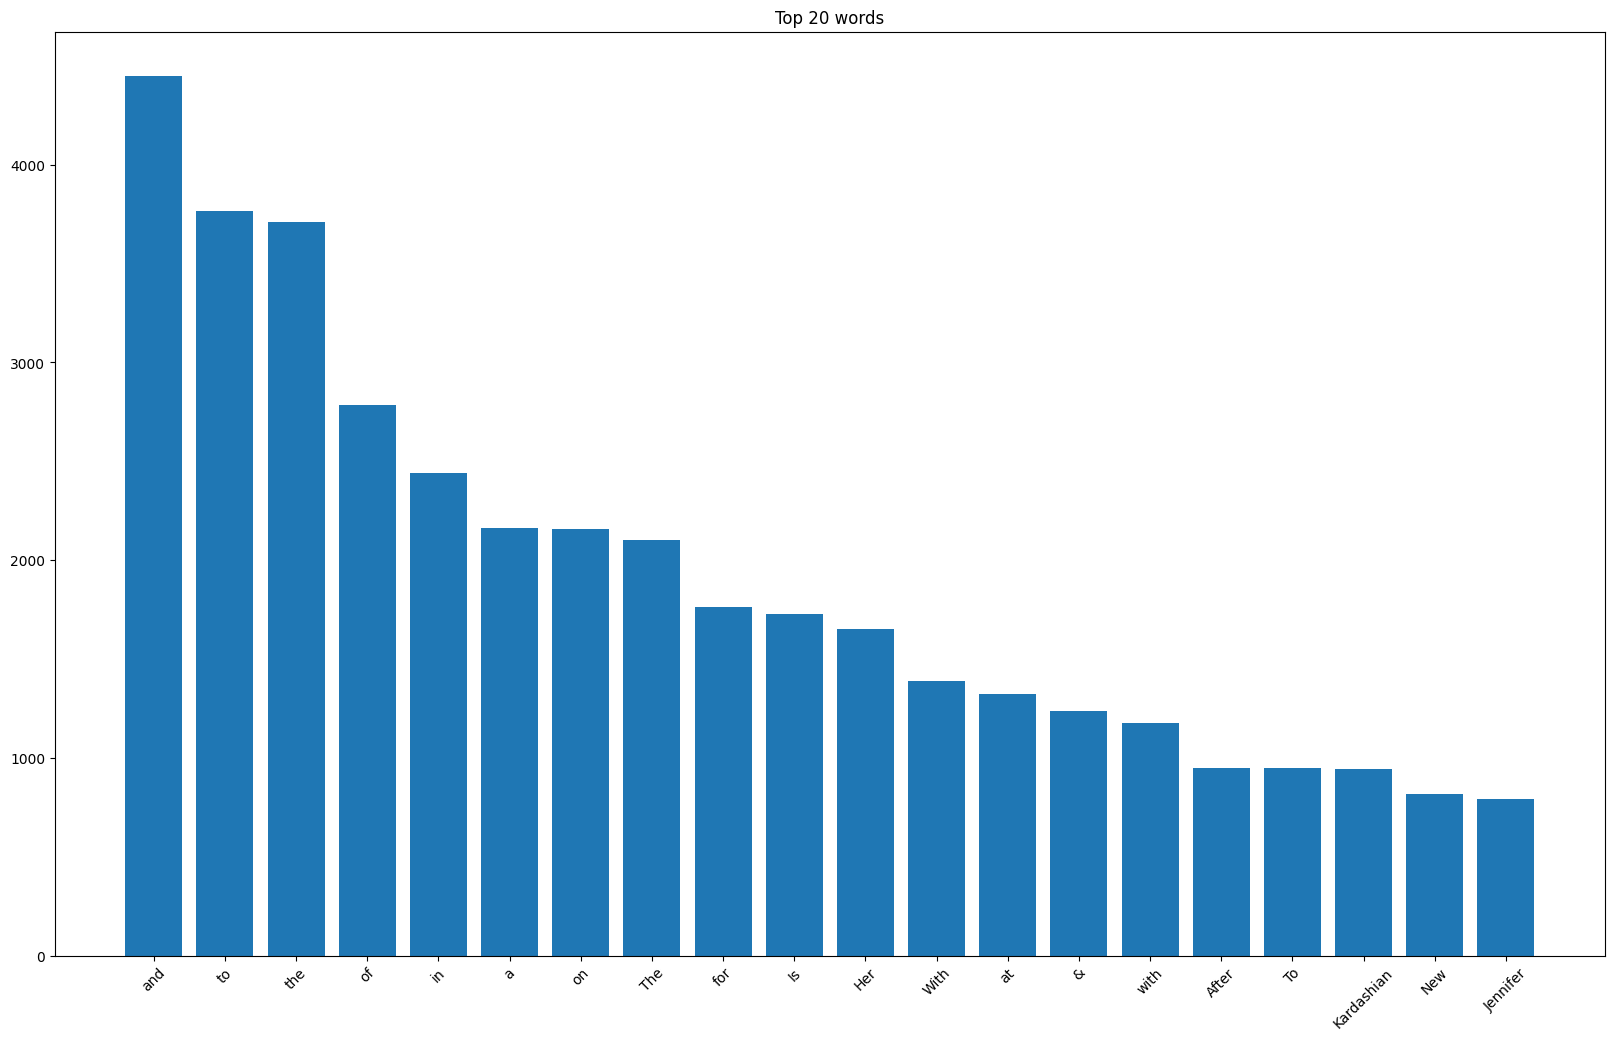

In [ ]:
top_words = Counter(words).most_common(20)
words_df = pd.DataFrame(
    top_words,
    columns=['Word', 'count']
)

plt.figure(figsize=(20, 12))
plt.bar(words_df['Word'], words_df['count'])
plt.xticks(rotation=45)
plt.title("Top 20 words")
plt.show()

In [ ]:
df = df[['title', 'tweet_num', 'real','source_domain']]

df.head()

,title,tweet_num,real,source_domain
0,Kandi Burruss Explodes Over Rape Accusation on...,42,1,toofab.com
1,People's Choice Awards 2018: The best red carp...,0,1,www.today.com
2,Sophia Bush Sends Sweet Birthday Message to 'O...,63,1,www.etonline.com
3,Colombian singer Maluma sparks rumours of inap...,20,1,www.dailymail.co.uk
4,Gossip Girl 10 Years Later: How Upper East Sid...,38,1,www.zerchoo.com


In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    #convert in lowercase
    text = str(text).lower()
    #Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    #Remove Punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    #Remove Numbers
    text = re.sub(r'\d+', '', text)

    #Remove Extra Space
    text = text.strip()

    #Tokenization
    words = text.split()

    #Remove stopwords and lemitization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ''.join(words)


In [ ]:
#Using clean_text func to clean title

df['clean_title'] = df['title'].apply(clean_text)

df[['title', 'clean_title']].head(10)

,title,clean_title
0,Kandi Burruss Explodes Over Rape Accusation on...,kandiburrussexplodesrapeaccusationrealhousewif...
1,People's Choice Awards 2018: The best red carp...,peoplechoiceawardbestredcarpetlook
2,Sophia Bush Sends Sweet Birthday Message to 'O...,sophiabushsendssweetbirthdaymessageonetreehill...
3,Colombian singer Maluma sparks rumours of inap...,colombiansingermalumasparkrumourinappropriater...
4,Gossip Girl 10 Years Later: How Upper East Sid...,gossipgirlyearlateruppereastsidersshockedworld...
5,Gwen Stefani Got Dumped by Blake Shelton Over ...,gwenstefanigotdumpedblakesheltonjealousydramae...
6,Broward County Sheriff Fired For Lying About P...,browardcountysherifffiredlyingparkland
7,Amber Rose Shuts Down French Montana Dating Ru...,amberroseshutsfrenchmontanadatingrumorcallrapp...
8,Mindy Kaling makes first post-baby appearance ...,mindykalingmakefirstpostbabyappearancedisneyla...
9,Katharine McPhee Butchers Tony Nominations: “I...,katharinemcpheebutchertonynomination“idrinking”


In [ ]:
df[df['clean_title'].str.len() == 0]

,title,tweet_num,real,source_domain,clean_title
7872,"""On and On""",0,1,www.youtube.com,
11595,What Up with That,54,1,en.wikipedia.org,


In [ ]:
print(
    (df['clean_title'].str.len() == 0).sum()
)

2


In [ ]:
df = df[df['clean_title'].str.len() >0]

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [ ]:
X_text = tfidf.fit_transform(
    df['clean_title']
)

In [ ]:
y = df['real']
df.isnull().sum()

,0
title,0
tweet_num,0
real,0
source_domain,330
clean_title,0


In [ ]:
df['source_domain'] = df['source_domain'].fillna(df['source_domain'].mode()[0])

In [ ]:
ohe = OneHotEncoder(handle_unknown='ignore')
X_domain = ohe.fit_transform(df[['source_domain']])


In [ ]:
X_tweets = df[['tweet_num']].values

In [ ]:
X_text.shape

(23194, 5000)

In [ ]:

X = hstack([X_text, X_domain, X_tweets])

In [ ]:
X.shape

(23194, 7442)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape

(18555, 7442)

In [ ]:
X_test.shape

(4639, 7442)

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8124595818064237
Precision: 0.8687323943661972
Recall   : 0.8841743119266054
F1 Score : 0.876385336743393


In [ ]:
print("Classification report: ", classification_report(y_test, y_pred))

Classification report:                precision    recall  f1-score   support

           0       0.63      0.60      0.61      1151
           1       0.87      0.88      0.88      3488

    accuracy                           0.81      4639
   macro avg       0.75      0.74      0.74      4639
weighted avg       0.81      0.81      0.81      4639



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix: ", cm)

Confusion Matrix:  [[ 685  466]
 [ 404 3084]]


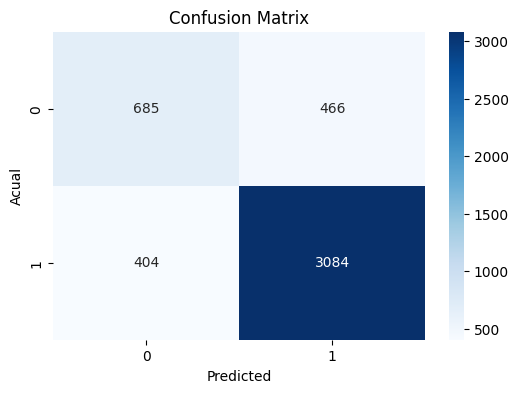

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Acual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
feature_names = tfidf.get_feature_names_out()
coefficient = model.coef_[0][:len(feature_names)]

In [ ]:
top_real = pd.DataFrame({
    "word": feature_names,
    "coef": coefficient
})

top_real.sort_values(
    by="coef",
    ascending=False
).head(20)

,word,coef
4923,watch,1.601035
118,bachelorparadise,1.554683
4837,transcript,1.519288
111,bachelorette,1.505174
4277,outlookofficeskypebingbreakingnewslatestvideo,1.442596
4590,sheknows,1.324404
3721,grey,1.296263
4763,thearrangement,1.110570
4538,seepic,1.004916
4742,tech,0.936188


In [ ]:
# Testing a custom headline with a fake domain
sample_title = ["Scientists discover new renewable energy technology"]
sample_domain = [["trustednews.com"]] # Must be a 2D list/array
sample_tweets = np.array([[0]])

# Transform everything using the ALREADY fitted vectorizers
sample_text_vec = tfidf.transform(sample_title)
sample_domain_vec = ohe.transform(sample_domain)

# Stack them in the exact same order
sample_vector = hstack([sample_text_vec, sample_domain_vec, sample_tweets])

# Predict!
print(model.predict(sample_vector))

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("classification_report: ", classification_report(y_test, rf_pred))

classification_report:                precision    recall  f1-score   support

           0       0.66      0.67      0.66      1151
           1       0.89      0.89      0.89      3488

    accuracy                           0.83      4639
   macro avg       0.77      0.78      0.78      4639
weighted avg       0.83      0.83      0.83      4639



In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_dept=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:20:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_dept" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("classification_report: ", classification_report(y_test, xgb_pred))

classification_report:                precision    recall  f1-score   support

           0       0.79      0.57      0.66      1151
           1       0.87      0.95      0.91      3488

    accuracy                           0.86      4639
   macro avg       0.83      0.76      0.79      4639
weighted avg       0.85      0.86      0.85      4639



In [ ]:
text = df['clean_title']
label = df['real']

In [ ]:
max_words = 10000

tokenizer = Tokenizer(
    num_words = max_words,
    oov_token = "<OOV>"
)

tokenizer.fit_on_texts(text)

In [ ]:
sequences = tokenizer.texts_to_sequences(text)

In [ ]:
max_length = 30

X = pad_sequences(
    sequences,
    maxlen= max_length,
    padding='post'
)

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [ ]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    ),
    LSTM(64),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
464/464 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7491 - loss: 0.5682 - val_accuracy: 0.7618 - val_loss: 0.5506
Epoch 2/5
464/464 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7494 - loss: 0.5663 - val_accuracy: 0.7618 - val_loss: 0.5490
Epoch 3/5
464/464 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.7494 - loss: 0.5653 - val_accuracy: 0.7618 - val_loss: 0.5521
Epoch 4/5
464/464 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7494 - loss: 0.5637 - val_accuracy: 0.7618 - val_loss: 0.5490
Epoch 5/5
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7494 - loss: 0.5646 - val_accuracy: 0.7618 - val_loss: 0.5512


In [ ]:
loss, accuracy = model.evaluate(X_valid, y_valid)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

 11/145 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7905 - loss: 0.5222 

145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7519 - loss: 0.5612
Test Loss: 0.5611801743507385
Test Accuracy: 0.7518861889839172


In [ ]:
y_prob = model.predict(X_valid)
y_preb = (y_prob > 0.5).astype(int)

145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
y_pred = y_pred.flatten()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.60      0.61      1151
           1       0.87      0.88      0.88      3488

    accuracy                           0.81      4639
   macro avg       0.75      0.74      0.74      4639
weighted avg       0.81      0.81      0.81      4639



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 685  466]
 [ 404 3084]]


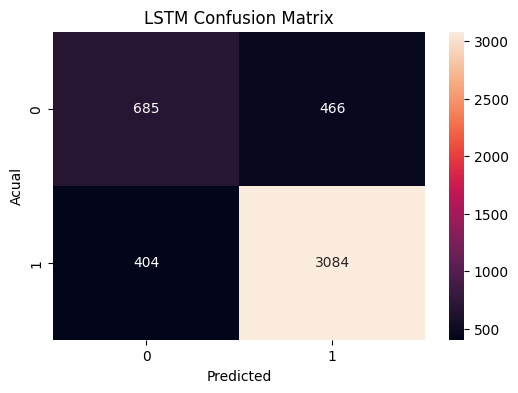

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Acual")
plt.show()

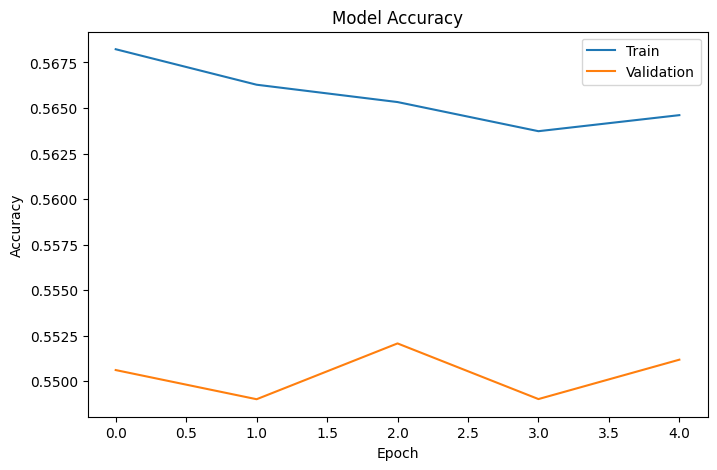

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend([
    "Train",
    'Validation'
])

plt.show()

In [ ]:
model.save("fake_news_lstm.h5")

In [ ]:
with open("model.plk", "wb") as f:
    pickle.dump(xgb, f)
with open('tfidf.pkl',"wb") as f:
    pickle.dump(tfidf, f)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.60      0.61      1151
           1       0.87      0.88      0.88      3488

    accuracy                           0.81      4639
   macro avg       0.75      0.74      0.74      4639
weighted avg       0.81      0.81      0.81      4639



In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.7518861889839172
